In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
# Load cleaned data from silver layer (repository-relative)
BASE_DIR = Path('..') / 'data' / 'silver'

transactions = pd.read_csv(BASE_DIR / 'transactions.csv')
outlet_master = pd.read_csv(BASE_DIR / 'outlet_master.csv')

print(f'Transactions shape: {transactions.shape}')
print(f'Outlet Master shape: {outlet_master.shape}')
print(f'\nTransactions columns: {list(transactions.columns)}')
print(f'Outlet Master columns: {list(outlet_master.columns)}')

Transactions shape: (2376389, 7)
Outlet Master shape: (20000, 4)

Transactions columns: ['Outlet_ID', 'Year', 'Month', 'Distributor_ID', 'SKU_ID', 'Volume_Liters', 'Total_Bill_Value']
Outlet Master columns: ['Outlet_ID', 'Outlet_Size', 'Cooler_Count', 'Outlet_Type']


In [17]:
# Merge transactions with outlet information
data = transactions.merge(outlet_master[['Outlet_ID', 'Outlet_Size', 'Outlet_Type']],
                           on='Outlet_ID', how='left')

# Calculate total sales by outlet
outlet_sales = data.groupby('Outlet_ID').agg({
    'Total_Bill_Value': ['sum', 'mean', 'count'],
    'Volume_Liters': ['sum', 'mean'],
    'Outlet_Type': 'first',
    'Outlet_Size': 'first'
}).round(2)

outlet_sales.columns = ['total_sales', 'avg_sale', 'transaction_count', 'total_volume', 'avg_volume', 'outlet_type', 'outlet_size']
outlet_sales = outlet_sales.reset_index()

print(f'\nOutlet-level aggregation:')
print(outlet_sales.head(10))
print(f'\nSummary statistics for total sales by outlet:')
print(outlet_sales['total_sales'].describe())


Outlet-level aggregation:
   Outlet_ID  total_sales  avg_sale  transaction_count  total_volume  \
0  OUT_00001   3884579.61  16600.77                234      15042.06   
1  OUT_00002   4363321.67  17882.47                244      16763.97   
2  OUT_00003   4067375.63  16877.08                241      14745.36   
3  OUT_00004   4592106.77  17198.90                267      17931.87   
4  OUT_00005   4284585.05  17346.50                247      16489.21   
5  OUT_00006   3621339.26  17410.28                208      14511.85   
6  OUT_00007   3809868.63  17239.22                221      15249.66   
7  OUT_00008   4088168.73  17774.65                230      14525.81   
8  OUT_00009   3947002.76  17387.68                227      15613.24   
9  OUT_00010   4449285.64  17178.71                259      16859.71   

   avg_volume outlet_type  outlet_size  
0       64.28     Grocery       Medium  
1       68.70       Hotel        Small  
2       61.18    Pharmacy        Small  
3       67.16   

Outlier Percentage for Total Sales: 20.72%


/tmp/ipykernel_16628/952144821.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=outlet_sales, x='outlet_type', y='total_sales', ax=axes[1], palette='Set2', inner='quartile')


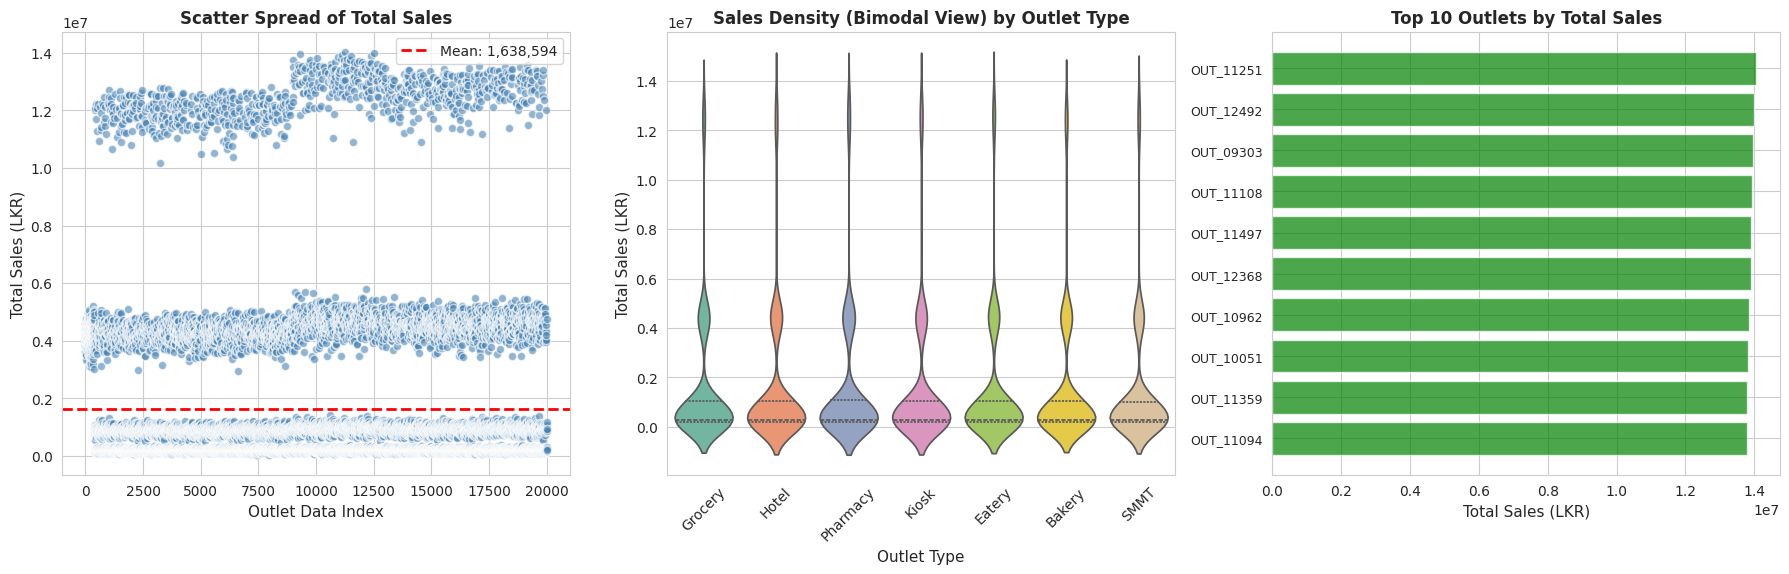

In [14]:
# WHAT: Calculate Q1, Q3, and IQR. WHY: To define mathematical outlier thresholds.
Q1 = outlet_sales['total_sales'].quantile(0.25)
Q3 = outlet_sales['total_sales'].quantile(0.75)
IQR = Q3 - Q1

# WHAT: Define 1.5*IQR bounds. WHY: Standard statistical limits for outlier detection.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# WHAT: Filter outliers and calculate percentage. WHY: To quantify extreme sales impact.
outliers = outlet_sales[(outlet_sales['total_sales'] < lower_bound) | (outlet_sales['total_sales'] > upper_bound)]
outlier_percentage = (len(outliers) / len(outlet_sales)) * 100

print(f"Outlier Percentage for Total Sales: {outlier_percentage:.2f}%")


# WHAT: Create 1x3 grid. WHY: Fits three plots efficiently without leaving blanks.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# WHAT: Scatter plot of total sales against index using alpha=0.6 and edgecolor='w'. WHY: Shows exact spread of individual data points instead of aggregated bins; alpha prevents solid blobs where data overlaps.
axes[0].scatter(range(len(outlet_sales)), outlet_sales['total_sales'], color='steelblue', alpha=0.6, edgecolor='w')
axes[0].set_xlabel('Outlet Data Index', fontsize=11)
axes[0].set_ylabel('Total Sales (LKR)', fontsize=11)
axes[0].set_title('Scatter Spread of Total Sales', fontsize=12, fontweight='bold')

# WHAT: Add horizontal mean line (axhline). WHY: Anchors the central tendency across the scattered points.
axes[0].axhline(outlet_sales['total_sales'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {outlet_sales["total_sales"].mean():,.0f}')
axes[0].legend()

# WHAT: Violin plot (sns.violinplot) grouped by outlet_type. WHY: Replaces the box plot to explicitly render KDE (Kernel Density Estimate) curves, allowing any bimodal "peaks" in the distribution to be visually obvious.
sns.violinplot(data=outlet_sales, x='outlet_type', y='total_sales', ax=axes[1], palette='Set2', inner='quartile')
axes[1].set_xlabel('Outlet Type', fontsize=11)
axes[1].set_ylabel('Total Sales (LKR)', fontsize=11)
axes[1].set_title('Sales Density (Bimodal View) by Outlet Type', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# WHAT: Get top 10 rows. WHY: Focuses analysis on highest performers.
top_10 = outlet_sales.nlargest(10, 'total_sales')

# WHAT: Plot horizontal bar chart. WHY: Readability for Outlet ID text labels.
axes[2].barh(range(len(top_10)), top_10['total_sales'].values, color='green', alpha=0.7)
axes[2].set_yticks(range(len(top_10)))
axes[2].set_yticklabels(top_10['Outlet_ID'].values, fontsize=9)
axes[2].set_xlabel('Total Sales (LKR)', fontsize=11)
axes[2].set_title('Top 10 Outlets by Total Sales', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

# WHAT: Apply tight layout. WHY: Prevents overlapping text and axes.
plt.tight_layout()
plt.show()

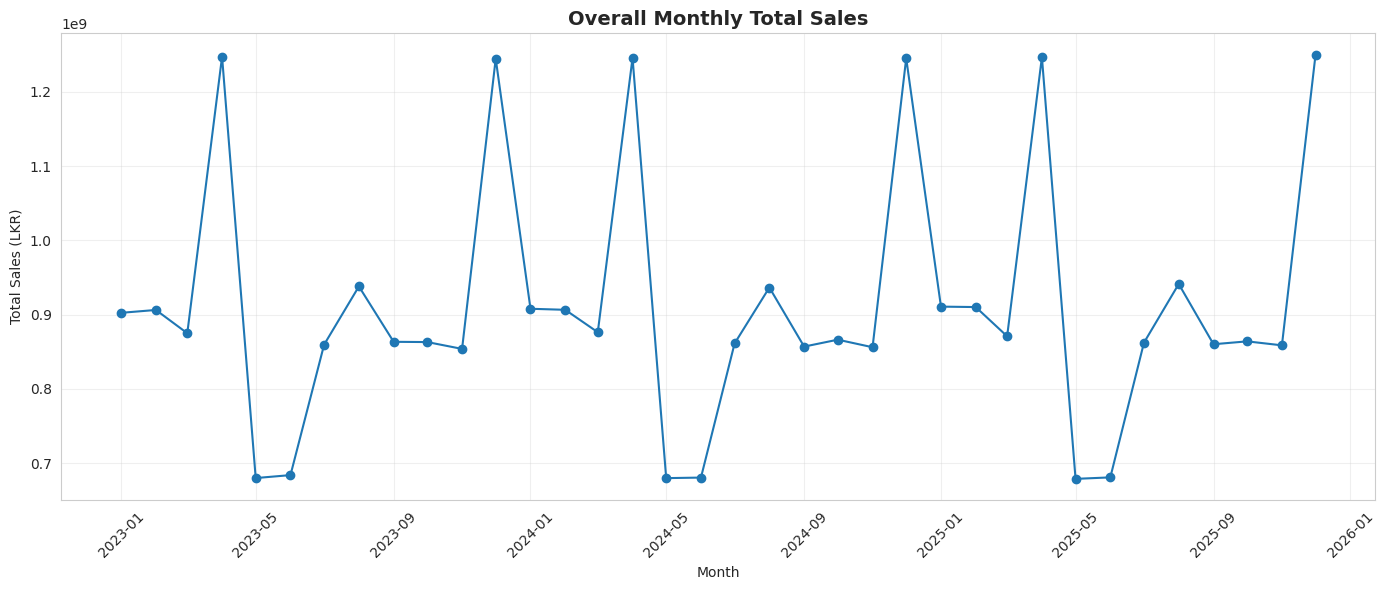

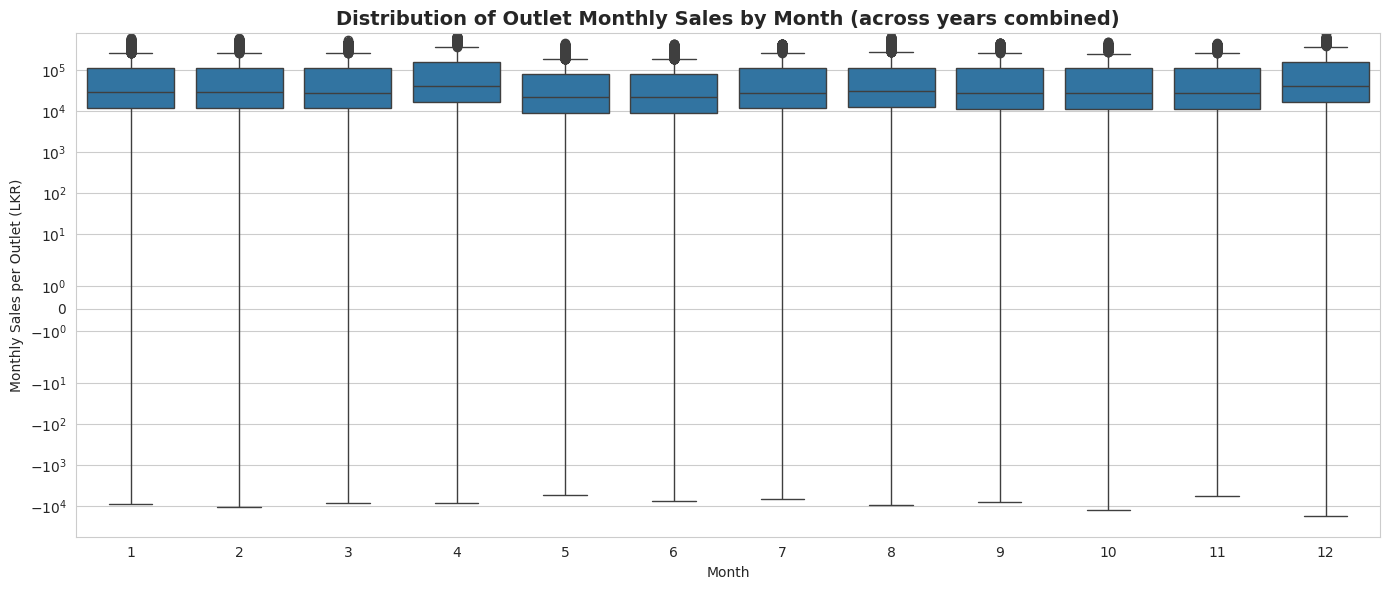

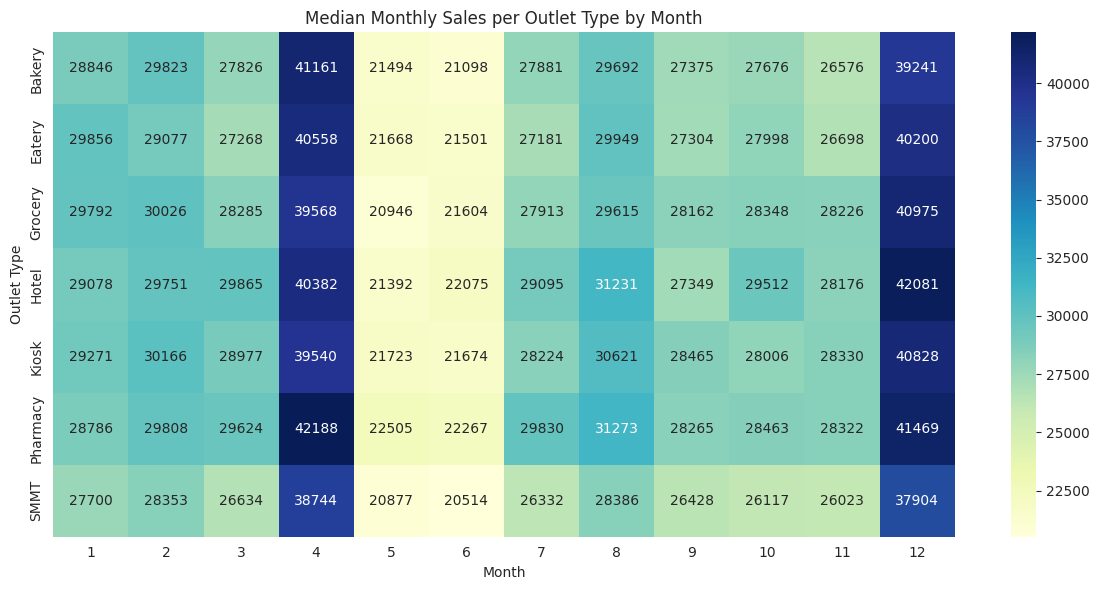

In [19]:

# Monthly Sales Analysis: overall trend and distribution across outlets
# Aggregate monthly totals across the whole dataset (by Year+Month)
monthly = data.groupby(['Year', 'Month'], as_index=False).agg({'Total_Bill_Value': 'sum', 'Volume_Liters': 'sum'})
monthly['month_label'] = pd.to_datetime(monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str) + '-01')

# Line plot: overall monthly total sales
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(monthly['month_label'], monthly['Total_Bill_Value'], marker='o', linestyle='-', color='C0')
ax.set_title('Overall Monthly Total Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (LKR)')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Distribution of monthly sales across outlets: compute outlet x month totals
outlet_month = data.groupby(['Outlet_ID', 'Year', 'Month'], as_index=False).agg({'Total_Bill_Value': 'sum'})
outlet_month['month_label'] = pd.to_datetime(outlet_month['Year'].astype(str) + '-' + outlet_month['Month'].astype(str) + '-01')

# Boxplot: distribution of outlet monthly totals for each month (shows how outlets vary month-to-month)
plt.figure(figsize=(14,6))
sns.boxplot(x=outlet_month['Month'].astype(int), y=outlet_month['Total_Bill_Value'])
plt.title('Distribution of Outlet Monthly Sales by Month (across years combined)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Monthly Sales per Outlet (LKR)')
plt.yscale('symlog')
plt.tight_layout()
plt.show()

# Heatmap: pivot of median outlet sales by month and outlet type (if available)
if 'Outlet_Type' in data.columns:
    pivot = outlet_month.merge(outlet_master[['Outlet_ID','Outlet_Type']], on='Outlet_ID', how='left')
    pivot2 = pivot.groupby(['Outlet_Type','Month'], as_index=False)['Total_Bill_Value'].median().pivot(index='Outlet_Type', columns='Month', values='Total_Bill_Value')
    plt.figure(figsize=(12,6))
    sns.heatmap(pivot2.fillna(0), annot=True, fmt='.0f', cmap='YlGnBu')
    plt.title('Median Monthly Sales per Outlet Type by Month')
    plt.xlabel('Month')
    plt.ylabel('Outlet Type')
    plt.tight_layout()
    plt.show()
